# Event Weight Diagnostics and Generation-Level Effective Area

This notebook inspects LeptonInjector/LeptonWeighter event weights stored in CSV files.

The main object is `oneweight`, computed upstream with `weighter.get_oneweight(event)`. From the LeptonWeighter source code, this is not a pure inverse generation spectrum. It includes interaction/cross-section information divided by the generation probability. Therefore, the `oneweight` energy scaling is not expected to be only the inverse of the generated spectrum.

Important interpretation used throughout this notebook:

- **Unweighted plots** check the Monte Carlo generation phase space.
- **LIW-weighted plots** show the contribution of each generated event under a flat incident flux convention.
- **Astrophysical flux-weighted plots** are made by multiplying `oneweight` by an external flux shape, for example `E^-3`.
- **Effective area plots here are generation-level / interaction-level only**, because the current dataset contains generated events before PMT response, trigger, reconstruction, or analysis cuts.

## 1. Imports, configuration, and helper functions

All imports are kept in this first code cell. The rest of the notebook reuses these imports and helper functions.

In [1]:
from pathlib import Path

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# User configuration
# -----------------------------------------------------------------------------
DATA_DIR = Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC")
CSV_PATTERN = "*.csv"

# Generated spectral index used by LeptonInjector.
# If PowerLawIndex = 1.5, the generation spectrum is approximately dN/dE ~ E^-1.5.
GENERATED_POWER_INDEX = 1.5

# Optional astrophysical flux shape for later checks: Phi(E) ~ E^-gamma.
ASTRO_GAMMA = 3.0


# -----------------------------------------------------------------------------
# Plot defaults
# -----------------------------------------------------------------------------
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# -----------------------------------------------------------------------------
# Helper functions
# -----------------------------------------------------------------------------
def load_event_weight_csvs(data_dir: Path, pattern: str = "*.csv") -> pd.DataFrame:
    """Load all CSV files in a directory and concatenate them into one DataFrame."""
    files = sorted(data_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {data_dir} with pattern {pattern!r}")

    frames = []
    empty_files = []
    for file in files:
        df_file = pd.read_csv(file)
        if len(df_file) == 0:
            empty_files.append(file.name)
        else:
            frames.append(df_file)

    if not frames:
        raise ValueError(f"All CSV files are empty in {data_dir}")

    df_loaded = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(files)} CSV files")
    print(f"Non-empty files: {len(frames)}")
    print(f"Empty files: {len(empty_files)}")
    print(f"Total rows: {len(df_loaded):,}")
    if empty_files:
        print("Example empty files:", empty_files[:10])

    return df_loaded


def clean_event_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Keep rows with finite positive energy and oneweight, and finite zenith."""
    required = ["energy", "oneweight", "zenith"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    valid = (
        np.isfinite(df["energy"]) &
        np.isfinite(df["oneweight"]) &
        np.isfinite(df["zenith"]) &
        (df["energy"] > 0) &
        (df["oneweight"] > 0)
    )

    cleaned = df.loc[valid].copy()
    cleaned["cos_zenith"] = np.cos(cleaned["zenith"].values)

    if "columnDepth" in cleaned.columns:
        cleaned["columnDepth"] = pd.to_numeric(cleaned["columnDepth"], errors="coerce")

    print(f"Rows before cleaning: {len(df):,}")
    print(f"Rows after cleaning:  {len(cleaned):,}")
    return cleaned


def log_bin_centers(edges: np.ndarray) -> np.ndarray:
    """Return geometric bin centers for log-spaced bins."""
    return np.sqrt(edges[:-1] * edges[1:])


def binned_median_fit(x: np.ndarray, y: np.ndarray, bins: np.ndarray, min_count: int = 20):
    """Fit log10(y) vs log10(x) using medians inside log10(x) bins."""
    logx = np.log10(x)
    logy = np.log10(y)
    bin_id = np.digitize(logx, bins)

    x_med = []
    y_med = []
    counts = []

    for i in range(1, len(bins)):
        mask = bin_id == i
        if mask.sum() >= min_count:
            x_med.append(np.median(logx[mask]))
            y_med.append(np.median(logy[mask]))
            counts.append(mask.sum())

    x_med = np.array(x_med)
    y_med = np.array(y_med)
    counts = np.array(counts)

    if len(x_med) < 2:
        raise ValueError("Not enough populated bins for a median fit")

    slope, intercept = np.polyfit(x_med, y_med, 1)
    return slope, intercept, x_med, y_med, counts


def fit_power_law(x: np.ndarray, y: np.ndarray):
    """Fit y ~ x^slope using positive finite values."""
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if mask.sum() < 2:
        raise ValueError("Not enough positive finite points for power-law fit")
    slope, intercept = np.polyfit(np.log10(x[mask]), np.log10(y[mask]), 1)
    return slope, intercept, mask


def weighted_histogram(x: np.ndarray, bins: np.ndarray, weights: np.ndarray | None = None):
    """Return histogram and bin centers."""
    hist, edges = np.histogram(x, bins=bins, weights=weights)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return hist, centers, edges


def safe_log_step(x: np.ndarray, y: np.ndarray, *, label: str | None = None, linewidth: float = 2):
    """Draw a step plot only for positive y values, useful for log-scale plots."""
    mask = np.isfinite(x) & np.isfinite(y) & (y > 0)
    plt.step(x[mask], y[mask], where="mid", label=label, linewidth=linewidth)

## 2. Load the event-weight CSV files

This loads all partial CSV files produced by the LIW pipeline. Empty files are reported but ignored during concatenation.

In [2]:
df_raw = load_event_weight_csvs(DATA_DIR, CSV_PATTERN)
df_raw.head()

Loaded 742 CSV files
Non-empty files: 742
Empty files: 0
Total rows: 146,638


,RunID,SubrunID,EventID,SubEventID,energy,zenith,azimuth,finalStateX,finalStateY,columnDepth,oneweight,initialType,finalType1,finalType2
0,0,4294967295,1,0,119.300665,2.129418,1.378987,0.268484,0.184845,2.825059e+05,1.647018e+05,NaN,NaN,NaN
1,0,4294967295,2,0,1238.180012,0.531102,6.000682,0.005477,0.386803,3.862402e+05,7.377209e+07,NaN,NaN,NaN
2,0,4294967295,3,0,51860.900970,1.597728,4.663098,0.009281,0.303531,2.559217e+06,2.491368e+12,NaN,NaN,NaN
3,0,4294967295,4,0,121.480201,1.724817,3.056408,0.631675,0.269485,4.028338e+05,2.457609e+05,NaN,NaN,NaN
4,0,4294967295,5,0,1805.314939,0.993945,1.746629,0.051028,0.883309,6.050514e+05,2.886543e+08,NaN,NaN,NaN


## 3. Basic bookkeeping checks

These checks count unique event identifiers. They help verify whether the merged table has repeated or missing identifiers.

Expected behavior: `EventID` should usually have many unique values. If the number of unique rows is much lower than the total row count, check whether the same events were merged multiple times.

In [ ]:
for column in ["RunID", "SubrunID", "EventID", "SubEventID"]:
    if column in df_raw.columns:
        print(f"{column}: {df_raw[column].nunique():,} unique values")
    else:
        print(f"{column}: missing")

print(f"Total rows: {len(df_raw):,}")

RunID: 742 unique values
SubrunID: 1 unique values
EventID: 200 unique values
SubEventID: 1 unique values
Total rows: 146,638


## 4. Clean the DataFrame

The following analysis only uses rows with finite positive `energy` and `oneweight`, and finite `zenith`.

In [ ]:
df = clean_event_dataframe(df_raw)

E = df["energy"].to_numpy()
W = df["oneweight"].to_numpy()
zenith = df["zenith"].to_numpy()
cosz = df["cos_zenith"].to_numpy()

print(df[["energy", "oneweight", "zenith", "cos_zenith"]].describe())

Rows before cleaning: 146,638
Rows after cleaning:  146,638
             energy     oneweight         zenith     cos_zenith
count  1.466380e+05  1.466380e+05  146638.000000  146638.000000
mean   3.051343e+04  1.073890e+14       1.569270       0.001444
std    3.142514e+05  2.649394e+15       0.683224       0.576942
min    1.000013e+02  1.021390e+05       0.002962      -0.999995
25%    1.768811e+02  5.843829e+05       1.045257      -0.497865
50%    3.964525e+02  5.350746e+06       1.567915       0.002882
75%    1.558593e+03  2.280988e+08       2.091931       0.501680
max    9.949970e+06  1.583381e+17       3.138529       0.999996


## 5. Main generation and LIW sanity checks

This section makes three checks:

1. **LIW vs energy**: We fit binned medians instead of fitting every scatter point. The LIW slope is not expected to be exactly `+1.5`, because `get_oneweight` contains interaction/cross-section information as well as the inverse generation probability.
2. **Zenith generation**: If generation was uniform in solid angle, the unweighted `cos(zenith)` histogram should be approximately flat.
3. **Unweighted energy spectrum in log bins**: With log-spaced energy bins, `counts per log-energy bin` has a slope shifted by `+1` relative to `dN/dE`.

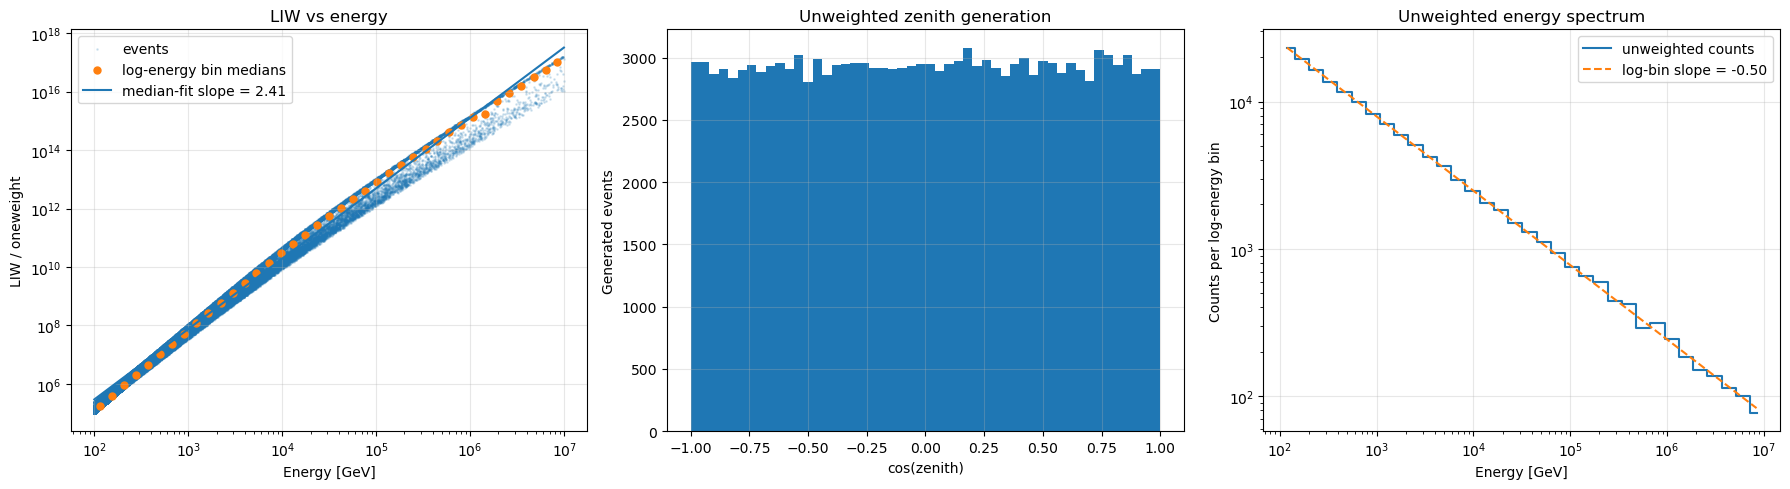

LIW vs energy binned-median slope: 2.408
Energy histogram log-bin slope:    -0.505

Interpretation:
- LIW is not expected to scale only as E^{+1.5}; it also contains interaction/cross-section effects.
- If dN/dE ~ E^{-1.5}, then counts in log-spaced bins look roughly like E^{-0.5}.


In [5]:
logE = np.log10(E)
logW = np.log10(W)

# LIW vs energy: fit binned medians in log-energy bins.
median_bins = np.linspace(logE.min(), logE.max(), 40)
liw_slope, liw_intercept, x_med, y_med, median_counts = binned_median_fit(
    E, W, median_bins, min_count=20
)

energy_range = np.logspace(logE.min(), logE.max(), 200)
liw_fit = 10**liw_intercept * energy_range**liw_slope

# Counts per log-energy bin.
energy_bins = np.logspace(logE.min(), logE.max(), 35)
counts, energy_edges = np.histogram(E, bins=energy_bins)
energy_centers = log_bin_centers(energy_edges)

energy_slope_logbin, energy_intercept_logbin, nonzero_logbin = fit_power_law(
    energy_centers, counts
)
energy_fit_logbin = 10**energy_intercept_logbin * energy_centers**energy_slope_logbin

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. LIW vs energy.
axes[0].scatter(E, W, alpha=0.15, s=1, label="events")
axes[0].scatter(10**x_med, 10**y_med, s=25, label="log-energy bin medians")
axes[0].plot(energy_range, liw_fit, label=f"median-fit slope = {liw_slope:.2f}")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Energy [GeV]")
axes[0].set_ylabel("LIW / oneweight")
axes[0].set_title("LIW vs energy")
axes[0].legend()

# 2. Unweighted zenith generation.
axes[1].hist(cosz, bins=50)
axes[1].set_xlabel("cos(zenith)")
axes[1].set_ylabel("Generated events")
axes[1].set_title("Unweighted zenith generation")

# 3. Counts per log-energy bin.
axes[2].step(energy_centers, counts, where="mid", label="unweighted counts")
axes[2].plot(energy_centers[nonzero_logbin], energy_fit_logbin[nonzero_logbin],
             linestyle="--", label=f"log-bin slope = {energy_slope_logbin:.2f}")
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("Energy [GeV]")
axes[2].set_ylabel("Counts per log-energy bin")
axes[2].set_title("Unweighted energy spectrum")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"LIW vs energy binned-median slope: {liw_slope:.3f}")
print(f"Energy histogram log-bin slope:    {energy_slope_logbin:.3f}")
print()
print("Interpretation:")
print("- LIW is not expected to scale only as E^{+1.5}; it also contains interaction/cross-section effects.")
print("- If dN/dE ~ E^{-1.5}, then counts in log-spaced bins look roughly like E^{-0.5}.")

## 6. Direct generated `dN/dE` estimate

Here the histogram is divided by the linear bin width `ΔE`, so the fitted slope estimates the generated `dN/dE` more directly.

Expected behavior: if the LeptonInjector generation `PowerLawIndex` is `1.5`, this slope should be close to `-1.5`, within MC statistics.

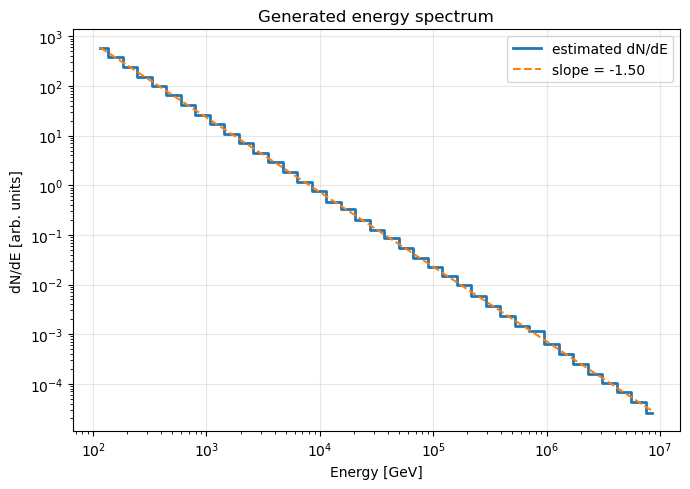

Measured generated dN/dE slope: -1.504
Expected approximate slope:     -1.500


In [7]:
dnde_bins = np.logspace(logE.min(), logE.max(), 40)
dnde_counts, dnde_edges = np.histogram(E, bins=dnde_bins)
dnde_centers = log_bin_centers(dnde_edges)
dnde_widths = np.diff(dnde_edges)
dnde = dnde_counts / dnde_widths

dnde_slope, dnde_intercept, dnde_mask = fit_power_law(dnde_centers, dnde)
dnde_fit = 10**dnde_intercept * dnde_centers**dnde_slope

plt.figure()
safe_log_step(dnde_centers, dnde, label="estimated dN/dE")
plt.plot(dnde_centers[dnde_mask], dnde_fit[dnde_mask], linestyle="--",
         label=f"slope = {dnde_slope:.2f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel("dN/dE [arb. units]")
plt.title("Generated energy spectrum")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Measured generated dN/dE slope: {dnde_slope:.3f}")
print(f"Expected approximate slope:     {-GENERATED_POWER_INDEX:.3f}")

## 7. LIW distribution

This shows the distribution of raw `oneweight` values. Large weight tails are common and can dominate weighted sums.

Expected behavior: a wide distribution is normal. If the largest weights dominate a plot, use median/mean/outlier diagnostics before making a physics interpretation.

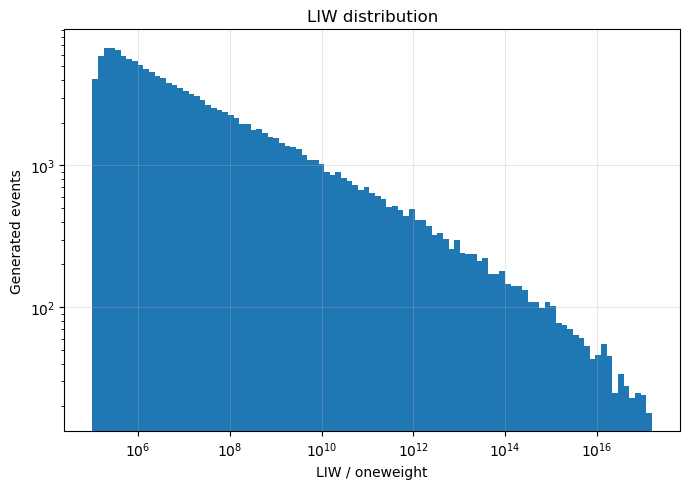

min:    1.021390e+05
median: 5.350746e+06
max:    1.583381e+17


In [8]:
weight_bins = np.logspace(np.log10(W.min()), np.log10(W.max()), 100)

plt.figure()
plt.hist(W, bins=weight_bins)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("LIW / oneweight")
plt.ylabel("Generated events")
plt.title("LIW distribution")
plt.tight_layout()
plt.show()

print(f"min:    {W.min():.6e}")
print(f"median: {np.median(W):.6e}")
print(f"max:    {W.max():.6e}")

## 8. Check whether LIW is only inverse generation

This plot divides `oneweight` by `E^1.5`. If LIW were only undoing the generated `E^-1.5` spectrum, this ratio would be roughly flat.

Expected behavior: it is not required to be flat, because LIW also contains interaction/cross-section effects.

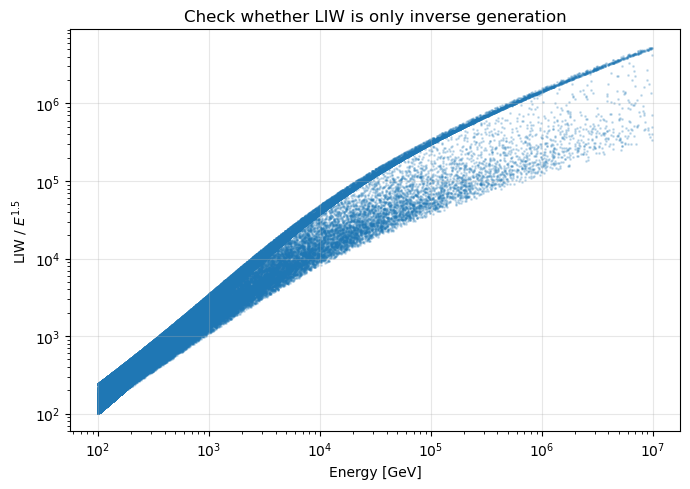

In [9]:
plt.figure()
plt.scatter(E, W / E**GENERATED_POWER_INDEX, s=1, alpha=0.2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel(rf"LIW / $E^{{{GENERATED_POWER_INDEX}}}$")
plt.title("Check whether LIW is only inverse generation")
plt.tight_layout()
plt.show()

## 9. Column depth versus zenith

`columnDepth` encodes the amount of material along the event direction. It can introduce zenith-dependent behavior in LIW-weighted plots.

Expected behavior: if the Earth path length changes with zenith, `columnDepth` should not be flat in `cos(zenith)`.

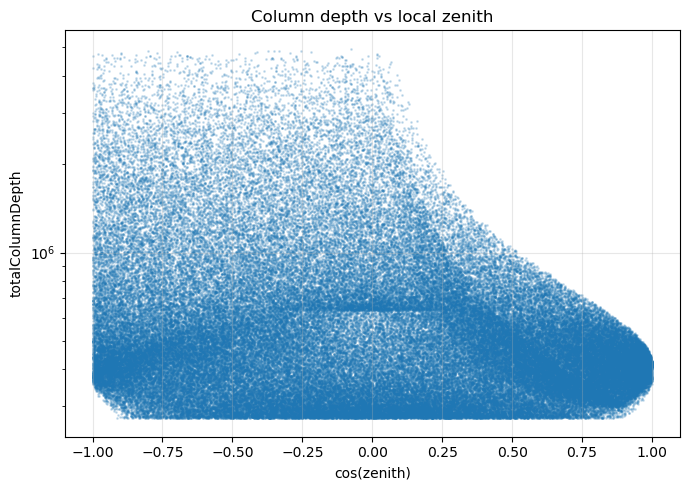

In [10]:
if "columnDepth" in df.columns:
    valid_cd = np.isfinite(df["columnDepth"].to_numpy()) & (df["columnDepth"].to_numpy() > 0)

    plt.figure()
    plt.scatter(cosz[valid_cd], df.loc[valid_cd, "columnDepth"], s=1, alpha=0.2)
    plt.yscale("log")
    plt.xlabel("cos(zenith)")
    plt.ylabel("totalColumnDepth")
    plt.title("Column depth vs local zenith")
    plt.tight_layout()
    plt.show()
else:
    print("columnDepth column is not available in this DataFrame.")

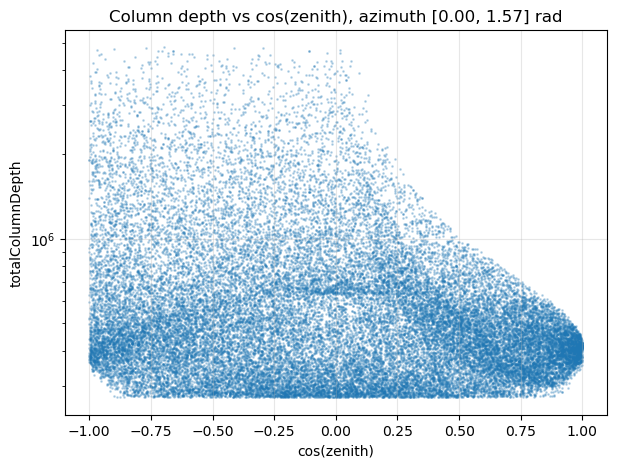

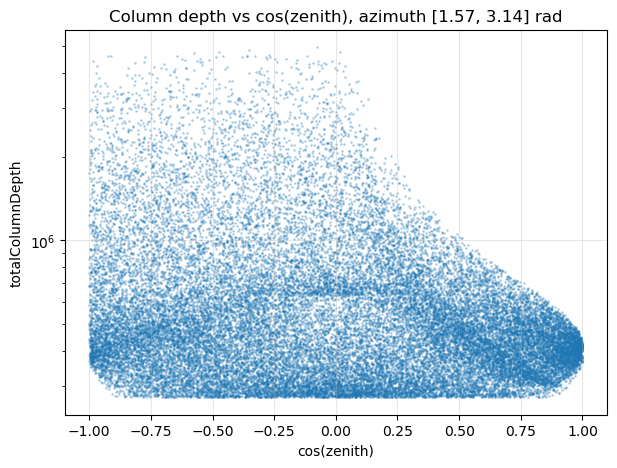

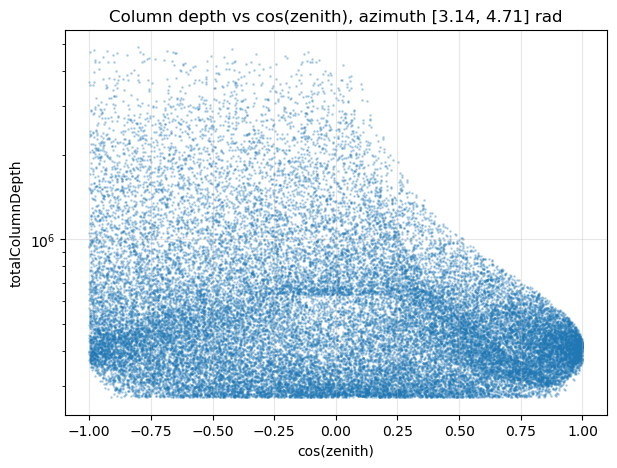

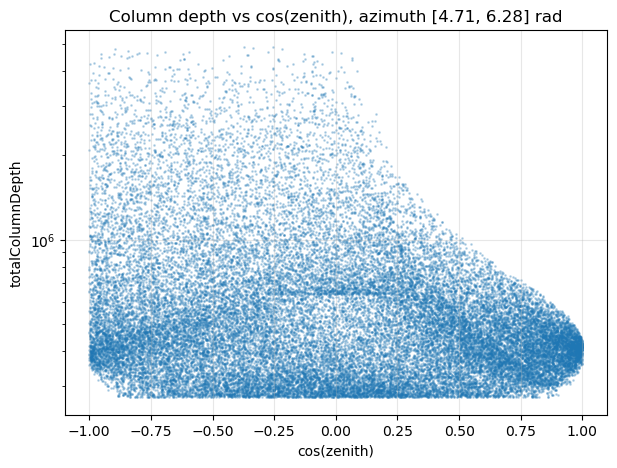

In [11]:


cosz = np.cos(df["zenith"].values)
az = df["azimuth"].values
X = df["columnDepth"].values if "columnDepth" in df.columns else df["totalColumnDepth"].values

valid = (
    np.isfinite(cosz) &
    np.isfinite(az) &
    np.isfinite(X) &
    (X > 0)
)

cosz = cosz[valid]
az = az[valid]
X = X[valid]

az_bins = [
    (0, np.pi/2),
    (np.pi/2, np.pi),
    (np.pi, 3*np.pi/2),
    (3*np.pi/2, 2*np.pi),
]

for amin, amax in az_bins:
    m = (az >= amin) & (az < amax)

    plt.figure(figsize=(7, 5))
    plt.scatter(cosz[m], X[m], s=1, alpha=0.25)
    plt.yscale("log")
    plt.xlabel("cos(zenith)")
    plt.ylabel("totalColumnDepth")
    plt.title(f"Column depth vs cos(zenith), azimuth [{amin:.2f}, {amax:.2f}] rad")
    plt.grid(alpha=0.3)
    plt.show()

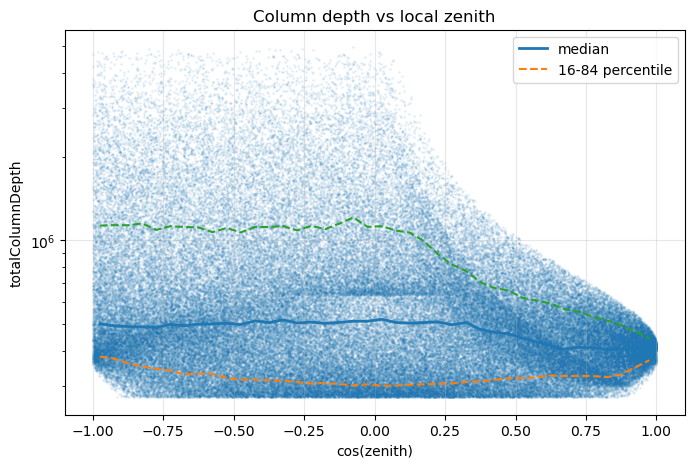

In [12]:
bins = np.linspace(-1, 1, 41)
centers = 0.5 * (bins[:-1] + bins[1:])

med = []
p16 = []
p84 = []

for lo, hi in zip(bins[:-1], bins[1:]):
    m = (cosz >= lo) & (cosz < hi)
    if m.sum() > 0:
        med.append(np.median(X[m]))
        p16.append(np.percentile(X[m], 16))
        p84.append(np.percentile(X[m], 84))
    else:
        med.append(np.nan)
        p16.append(np.nan)
        p84.append(np.nan)

plt.figure(figsize=(8, 5))
plt.scatter(cosz, X, s=1, alpha=0.08)
plt.plot(centers, med, linewidth=2, label="median")
plt.plot(centers, p16, linestyle="--", label="16-84 percentile")
plt.plot(centers, p84, linestyle="--")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("totalColumnDepth")
plt.title("Column depth vs local zenith")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
X = df["columnDepth"].values if "columnDepth" in df.columns else df["totalColumnDepth"].values

print("min:", np.nanmin(X))
print("1%:", np.nanpercentile(X, 1))
print("5%:", np.nanpercentile(X, 5))
print("median:", np.nanmedian(X))

# En küçük değerlere bakalım
small = np.sort(X[np.isfinite(X)])[:20]
print(small)

min: 272837.3676067057
1%: 275241.130441642
5%: 285643.3814705375
median: 457830.1870967444
[272837.36760671 272839.25264428 272840.00452979 272848.52080639
 272850.01672754 272850.07289835 272850.69078294 272850.71658908
 272851.28522182 272853.11313768 272854.04204405 272854.56834868
 272856.84653583 272858.10751118 272860.38512105 272860.74619944
 272860.89252197 272862.35474518 272866.35629407 272868.55567141]


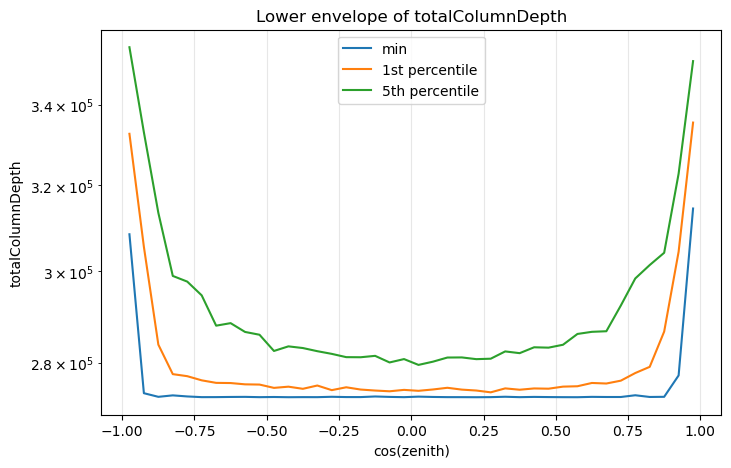

In [14]:
cosz = np.cos(df["zenith"].values)
X = df["columnDepth"].values if "columnDepth" in df.columns else df["totalColumnDepth"].values

bins = np.linspace(-1, 1, 41)
centers = 0.5 * (bins[:-1] + bins[1:])

xmin = []
x01 = []
x05 = []

for lo, hi in zip(bins[:-1], bins[1:]):
    m = (cosz >= lo) & (cosz < hi) & np.isfinite(X) & (X > 0)
    if m.sum() > 0:
        xmin.append(np.min(X[m]))
        x01.append(np.percentile(X[m], 1))
        x05.append(np.percentile(X[m], 5))
    else:
        xmin.append(np.nan)
        x01.append(np.nan)
        x05.append(np.nan)

plt.figure(figsize=(8, 5))
plt.plot(centers, xmin, label="min")
plt.plot(centers, x01, label="1st percentile")
plt.plot(centers, x05, label="5th percentile")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("totalColumnDepth")
plt.title("Lower envelope of totalColumnDepth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. LIW-weighted zenith distribution

This compares the unweighted generation distribution with the LIW-weighted distribution.

Expected behavior:

- The unweighted `cos(zenith)` distribution should be approximately flat if generation was uniform in solid angle.
- The LIW-weighted distribution does **not** have to be flat. It can reflect interaction probability, column depth, geometry, and weight outliers.

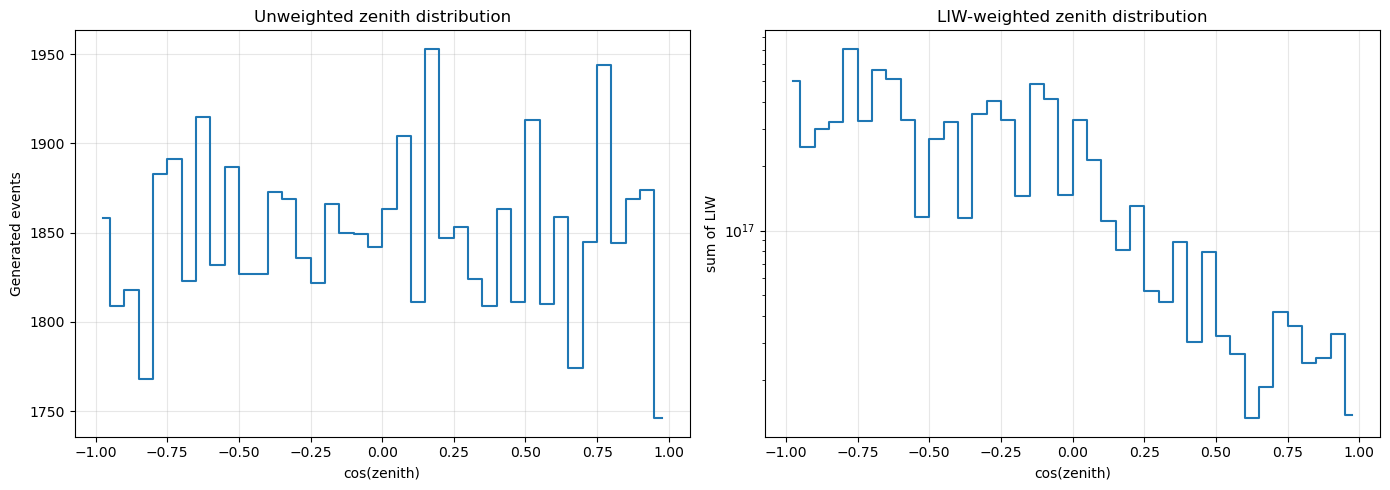

In [10]:
cosz_bins = np.linspace(-1, 1, 41)

unweighted_hist, cosz_centers, _ = weighted_histogram(cosz, cosz_bins)
weighted_hist, _, _ = weighted_histogram(cosz, cosz_bins, weights=W)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].step(cosz_centers, unweighted_hist, where="mid")
axes[0].set_xlabel("cos(zenith)")
axes[0].set_ylabel("Generated events")
axes[0].set_title("Unweighted zenith distribution")

axes[1].step(cosz_centers, weighted_hist, where="mid")
axes[1].set_yscale("log")
axes[1].set_xlabel("cos(zenith)")
axes[1].set_ylabel("sum of LIW")
axes[1].set_title("LIW-weighted zenith distribution")

plt.tight_layout()
plt.show()

## 11. Per-bin LIW statistics versus zenith

Weighted sums can be dominated by a few high-weight events. This section compares the sum, mean, median, and event count per zenith bin.

Expected behavior: the median is usually more stable than the sum or mean. If the sum is noisy but the median is smooth, the plot is likely dominated by outliers or limited MC statistics.

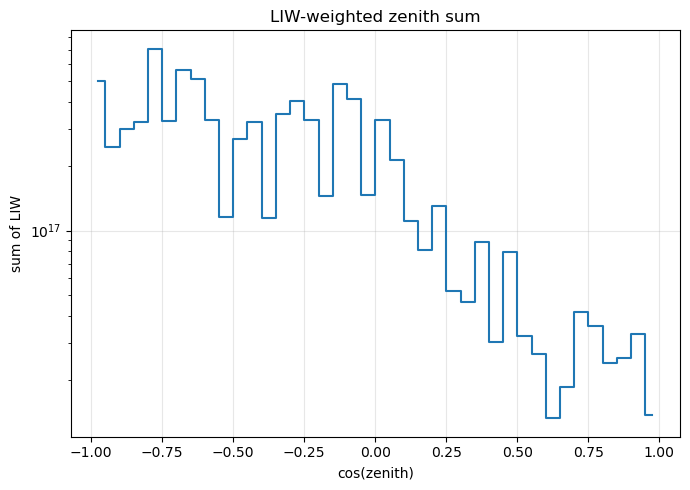

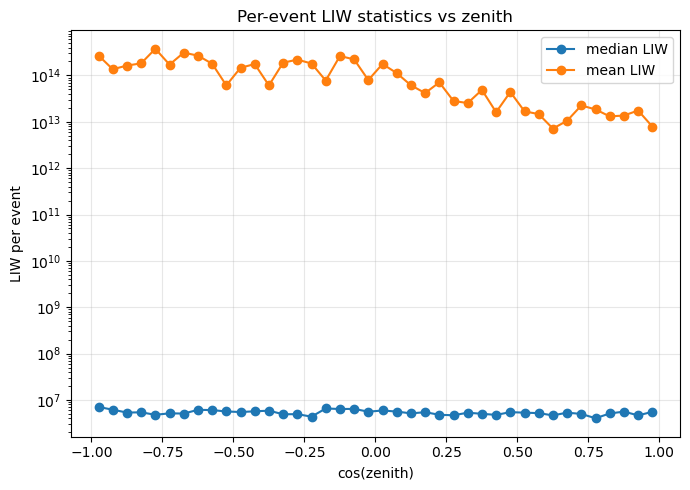

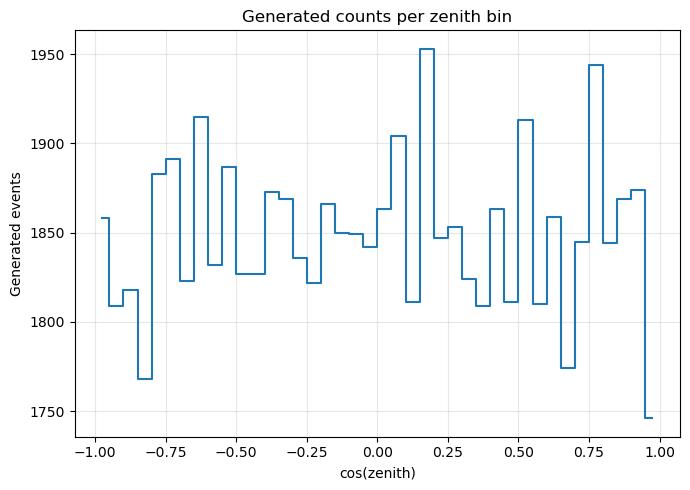

In [11]:
bin_id = np.digitize(cosz, cosz_bins)

x = []
sum_w = []
mean_w = []
median_w = []
counts = []

for i in range(1, len(cosz_bins)):
    mask = bin_id == i
    if mask.sum() == 0:
        continue

    x.append(0.5 * (cosz_bins[i - 1] + cosz_bins[i]))
    sum_w.append(np.sum(W[mask]))
    mean_w.append(np.mean(W[mask]))
    median_w.append(np.median(W[mask]))
    counts.append(mask.sum())

x = np.array(x)
sum_w = np.array(sum_w)
mean_w = np.array(mean_w)
median_w = np.array(median_w)
counts = np.array(counts)

plt.figure()
plt.step(x, sum_w, where="mid")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("sum of LIW")
plt.title("LIW-weighted zenith sum")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x, median_w, marker="o", label="median LIW")
plt.plot(x, mean_w, marker="o", label="mean LIW")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("LIW per event")
plt.title("Per-event LIW statistics vs zenith")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.step(x, counts, where="mid")
plt.xlabel("cos(zenith)")
plt.ylabel("Generated events")
plt.title("Generated counts per zenith bin")
plt.tight_layout()
plt.show()

## 12. Outlier diagnostics for LIW-weighted zenith bins

This checks whether each zenith bin is dominated by a single event.

Expected behavior: if `sum LIW / max LIW` is close to `1`, that bin is dominated by one event. In that case, the weighted histogram is statistically unstable and should not be over-interpreted.

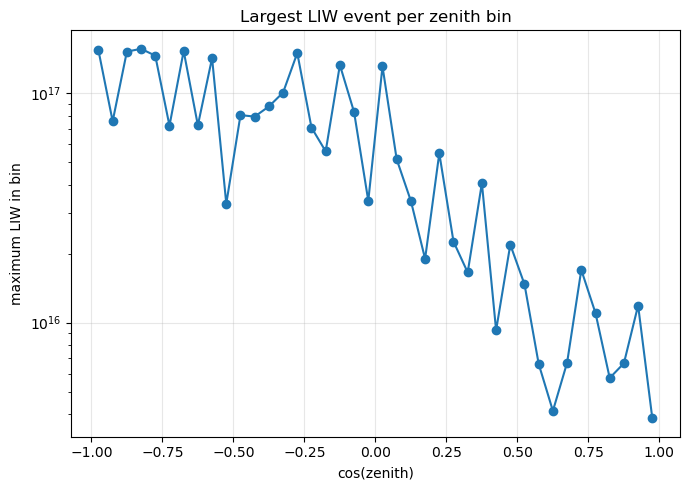

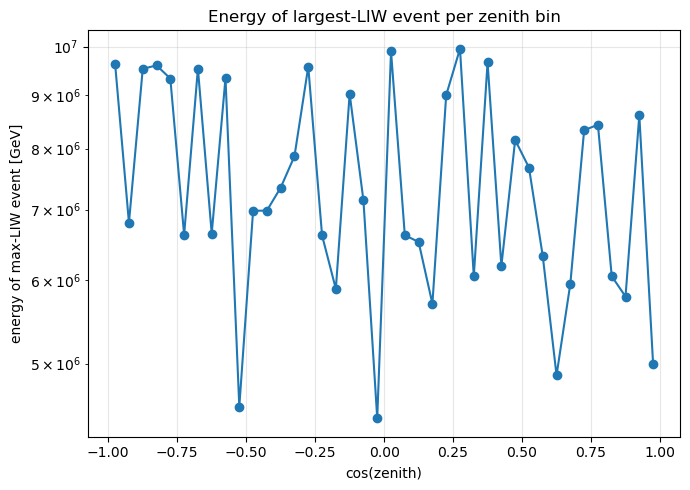

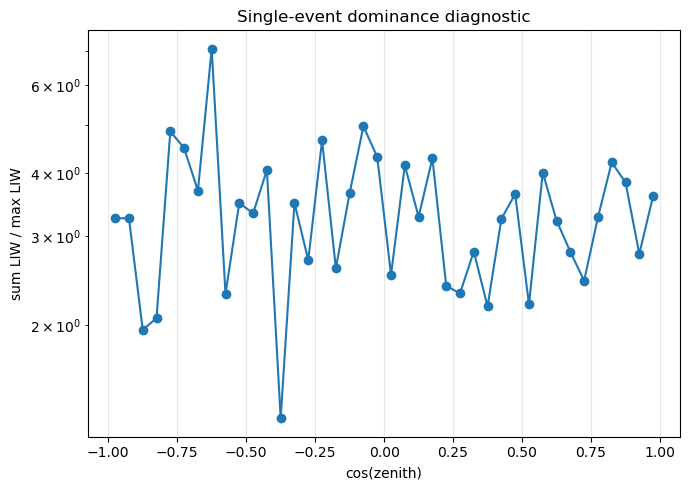

In [12]:
x_out = []
max_w = []
max_E = []
sum_w_out = []

for i in range(1, len(cosz_bins)):
    mask = bin_id == i
    if mask.sum() == 0:
        continue

    local_w = W[mask]
    local_E = E[mask]
    idx = np.argmax(local_w)

    x_out.append(0.5 * (cosz_bins[i - 1] + cosz_bins[i]))
    max_w.append(local_w[idx])
    max_E.append(local_E[idx])
    sum_w_out.append(np.sum(local_w))

x_out = np.array(x_out)
max_w = np.array(max_w)
max_E = np.array(max_E)
sum_w_out = np.array(sum_w_out)

plt.figure()
plt.plot(x_out, max_w, marker="o")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("maximum LIW in bin")
plt.title("Largest LIW event per zenith bin")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x_out, max_E, marker="o")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("energy of max-LIW event [GeV]")
plt.title("Energy of largest-LIW event per zenith bin")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x_out, sum_w_out / max_w, marker="o")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("sum LIW / max LIW")
plt.title("Single-event dominance diagnostic")
plt.tight_layout()
plt.show()

## 13. Apply an astrophysical power-law flux shape

The LIW pipeline should remain flux-free. To study an astrophysical flux with `Phi(E) ∝ E^-3`, multiply the existing `oneweight` by `E^-3` during analysis.

This is a shape-only weighting unless a physical flux normalization and livetime are also included.

Expected behavior: because LIW increases with energy, multiplying by `E^-3` suppresses high-energy events relative to the LIW-only case.

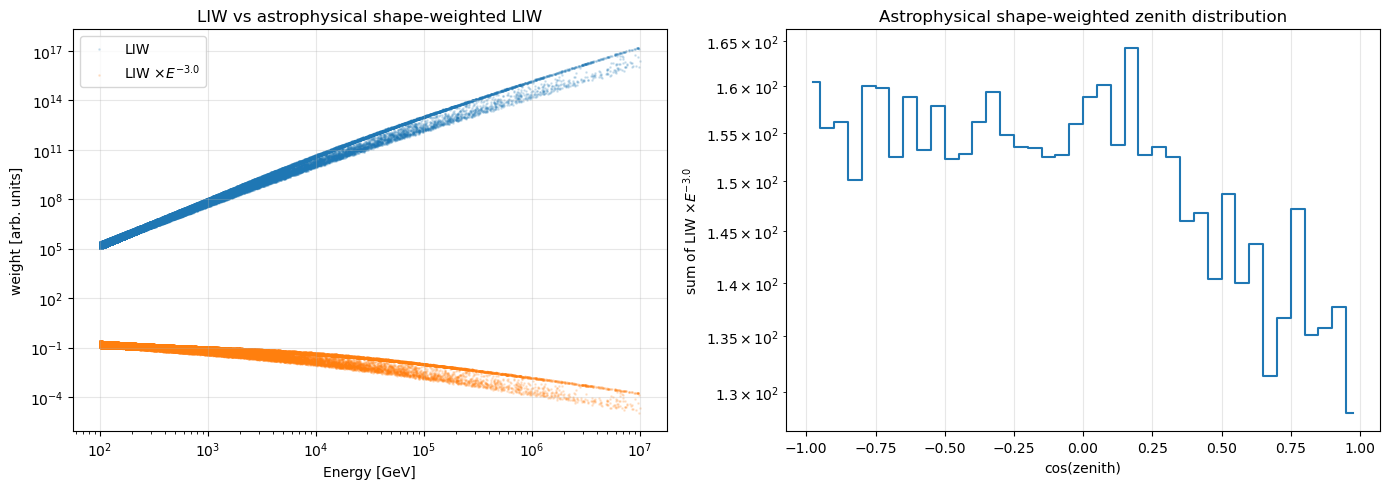

In [13]:
df["astro_weight_shape"] = df["oneweight"] * df["energy"]**(-ASTRO_GAMMA)

astro_W = df["astro_weight_shape"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(E, W, s=1, alpha=0.15, label="LIW")
axes[0].scatter(E, astro_W, s=1, alpha=0.15, label=rf"LIW $\times E^{{-{ASTRO_GAMMA}}}$")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Energy [GeV]")
axes[0].set_ylabel("weight [arb. units]")
axes[0].set_title("LIW vs astrophysical shape-weighted LIW")
axes[0].legend()

astro_hist, _, _ = weighted_histogram(cosz, cosz_bins, weights=astro_W)
axes[1].step(cosz_centers, astro_hist, where="mid")
axes[1].set_yscale("log")
axes[1].set_xlabel("cos(zenith)")
axes[1].set_ylabel(rf"sum of LIW $\times E^{{-{ASTRO_GAMMA}}}$")
axes[1].set_title("Astrophysical shape-weighted zenith distribution")

plt.tight_layout()
plt.show()

## 14. Generation-level all-sky averaged effective area

This computes a generation-level all-sky averaged effective area from LIW:

\[
A_{\rm eff}(E) \approx \frac{\sum_{i \in E\;\rm bin} w_i}{\Delta E\,\Delta\Omega}
\]

where `w_i = oneweight_i` and `ΔΩ = 4π` for the all-sky average.

Expected behavior: the curve often increases with energy because interaction probability/cross-section increases with energy. However, this is not a final detector-level effective area because PMT response, trigger, reconstruction, and analysis cuts are not applied.

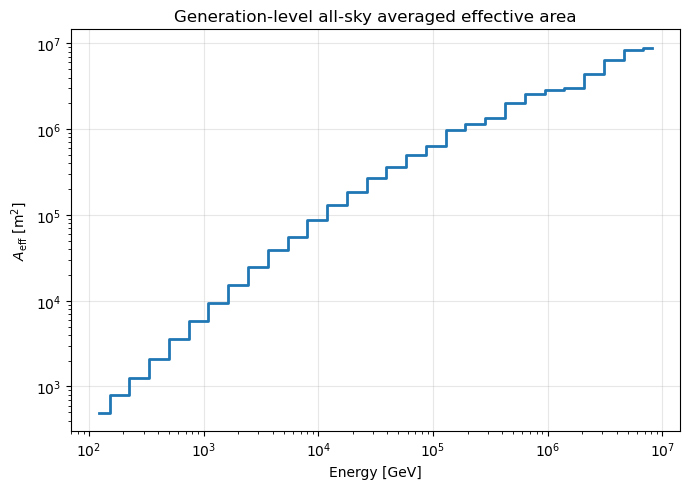

In [14]:
aeff_bins = np.logspace(logE.min(), logE.max(), 30)
aeff_sum_w, aeff_edges = np.histogram(E, bins=aeff_bins, weights=W)
aeff_centers = log_bin_centers(aeff_edges)
aeff_delta_E = np.diff(aeff_edges)

# Full-sky solid angle.
delta_omega_all_sky = 4 * np.pi

# oneweight convention here gives area in cm^2 after dividing by dE dOmega.
A_eff_cm2 = aeff_sum_w / (aeff_delta_E * delta_omega_all_sky)
A_eff_m2 = A_eff_cm2 / 1e4

plt.figure()
safe_log_step(aeff_centers, A_eff_m2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel(r"$A_{\rm eff}$ [m$^2$]")
plt.title("Generation-level all-sky averaged effective area")
plt.tight_layout()
plt.show()

## 15. Generation-level effective area by local zenith band

This separates the effective area by local `cos(zenith)` bands.

Important: this is **not true declination binning** for P-ONE. The relation `sin(delta) = cos(zenith)` is a special simplification for a detector at the pole. For P-ONE, use the detector latitude and event direction to compute true declination if needed.

Expected behavior: high-energy bins can be noisy because the `E^-1.5` generation spectrum leaves fewer events at high energy. Splitting into angular bands further reduces statistics.

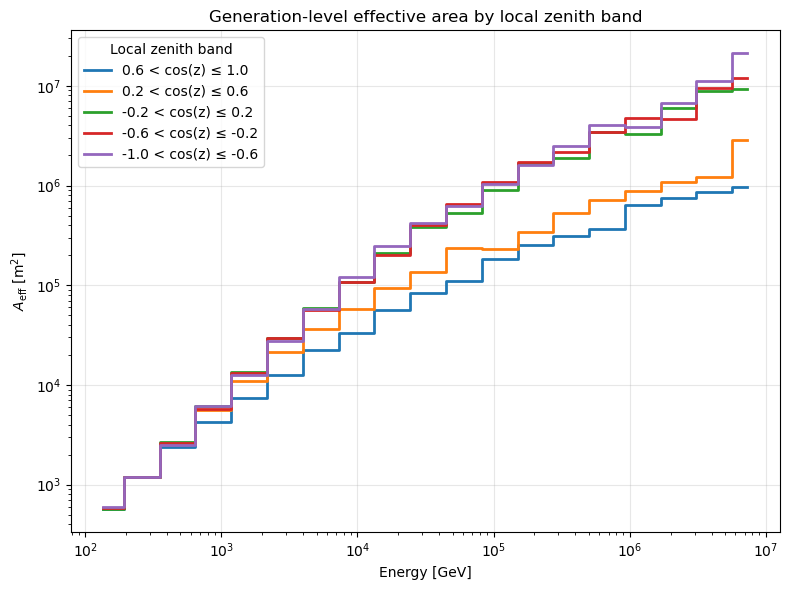

In [15]:
# Fewer energy bins make the banded plot more stable at high energy.
band_energy_bins = np.logspace(logE.min(), logE.max(), 20)
band_centers = log_bin_centers(band_energy_bins)
band_delta_E = np.diff(band_energy_bins)

cosz_bands = [
    (0.6, 1.0),
    (0.2, 0.6),
    (-0.2, 0.2),
    (-0.6, -0.2),
    (-1.0, -0.6),
]

plt.figure(figsize=(8, 6))

for band_min, band_max in cosz_bands:
    if band_max == 1.0:
        mask = (cosz >= band_min) & (cosz <= band_max)
    else:
        mask = (cosz >= band_min) & (cosz < band_max)

    sum_w_band, _ = np.histogram(E[mask], bins=band_energy_bins, weights=W[mask])
    counts_band, _ = np.histogram(E[mask], bins=band_energy_bins)

    delta_omega_band = 2 * np.pi * (band_max - band_min)
    A_eff_band_cm2 = sum_w_band / (band_delta_E * delta_omega_band)
    A_eff_band_m2 = A_eff_band_cm2 / 1e4

    nonzero = (sum_w_band > 0) & (counts_band > 0)
    plt.step(
        band_centers[nonzero],
        A_eff_band_m2[nonzero],
        where="mid",
        linewidth=2,
        label=f"{band_min:.1f} < cos(z) ≤ {band_max:.1f}",
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel(r"$A_{\rm eff}$ [m$^2$]")
plt.title("Generation-level effective area by local zenith band")
plt.legend(title="Local zenith band")
plt.tight_layout()
plt.show()

## 16. MC statistics by local zenith band

This diagnostic shows how many generated events exist in each energy and zenith band.

Expected behavior: the highest-energy bins may have very few events, especially after splitting into several angular bands. Noisy effective-area behavior in those bins should be interpreted as limited MC statistics.

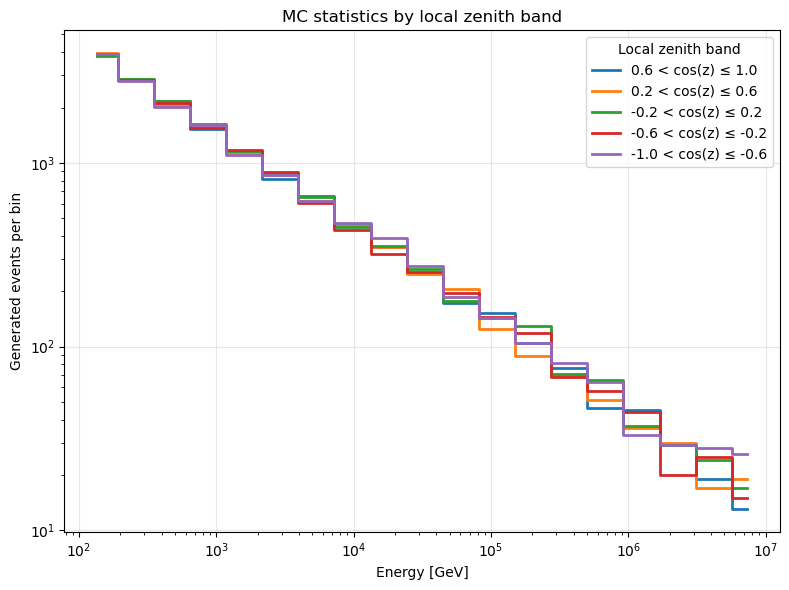

In [16]:
plt.figure(figsize=(8, 6))

for band_min, band_max in cosz_bands:
    if band_max == 1.0:
        mask = (cosz >= band_min) & (cosz <= band_max)
    else:
        mask = (cosz >= band_min) & (cosz < band_max)

    counts_band, _ = np.histogram(E[mask], bins=band_energy_bins)
    nonzero = counts_band > 0

    plt.step(
        band_centers[nonzero],
        counts_band[nonzero],
        where="mid",
        linewidth=2,
        label=f"{band_min:.1f} < cos(z) ≤ {band_max:.1f}",
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel("Generated events per bin")
plt.title("MC statistics by local zenith band")
plt.legend(title="Local zenith band")
plt.tight_layout()
plt.show()

## 17. Summary of what each plot checks

- **LIW vs energy**: checks the energy scaling of `oneweight`. It is not expected to be only `E^+1.5` because LIW includes interaction/cross-section effects.
- **Unweighted `cos(zenith)`**: checks whether the generated directions are uniform in solid angle.
- **Generated `dN/dE`**: checks whether the generated power law matches the configured `PowerLawIndex`.
- **Column depth vs zenith**: checks whether direction-dependent Earth/material effects enter the weighting.
- **LIW-weighted zenith**: shows the flat-flux LIW contribution by local zenith, but can be dominated by high-weight outliers.
- **Astrophysical shape weighting**: multiplies LIW by a chosen external flux shape such as `E^-3`.
- **Generation-level effective area**: uses LIW without applying any astrophysical flux. Since this dataset is before PMT response, trigger, reconstruction, and cuts, it should not be called final detector-level effective area.